In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
import config

# Verify data is accessible
try:
    config.assert_data_exists()
    print("✓ Data path:", config.DATA_ROOT)
except FileNotFoundError as e:
    print("✗ Data path error:", e)

# Data loading utility — use this instead of pd.read_csv() directly
# It handles column name cleaning (the CSV has spaces in headers)
def load_csv(path):
    """Load a CSV from config.DATA_RAW or config.DATA_PROCESSED with cleaned column names."""
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    # Also strip whitespace from all string/object column VALUES
    for col in df.select_dtypes(include=["object"]).columns:
        df[col] = df[col].str.strip()
    return df

# Example usage:
# df = load_csv(config.DATA_RAW / "Airlines.csv")
# df = load_csv(config.DATA_PROCESSED / "Airlines_enriched.csv")

✓ Data path: /Users/hareee234/Library/CloudStorage/GoogleDrive-hareee234@gmail.com/My Drive/sem-8/CMPE188/flight-delay-proj-data


# 00 — Dataset Date Period Investigation
**CMPE 188 | Flight Delay Prediction**

## Purpose

The `Airlines.csv` dataset has no date, month, or year column — only `DayOfWeek` (1–7).
The Kaggle dataset creator could not confirm the collection period. A community commenter
proposed *June 1, 2022* as the start date, but this is almost certainly incorrect.

This notebook systematically investigates the available evidence to narrow the collection window.

## Investigative Approach

1. **Airline code audit** — extinct carriers constrain the latest possible date
2. **DayOfWeek distribution** — uniformity test for partial-week effects
3. **Flight number patterns** — per-carrier distributions for BTS cross-reference
4. **Date range hypothesis** — evidence-based conclusion
5. **BTS validation** — programmatic matching against public On-Time Performance data (manual download required)
6. **Summary & implications**

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

DATA_PATH = str(config.DATA_RAW / 'Airlines.csv')

df = pd.read_csv(DATA_PATH)
# CSV has leading/trailing spaces in column names — strip them
df.columns = df.columns.str.strip()
# Also strip string values in categorical columns
for col in df.select_dtypes("object").columns:
    df[col] = df[col].str.strip()

print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
df.head()

Loaded 539,383 rows, 9 columns
Columns: ['id', 'Airline', 'Flight', 'AirportFrom', 'AirportTo', 'DayOfWeek', 'Time', 'Length', 'Delay']


,id,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,1,CO,269,SFO,IAH,3,15,205,1
1,2,US,1558,PHX,CLT,3,15,222,1
2,3,AA,2400,LAX,DFW,3,20,165,1
3,4,AA,2466,SFO,DFW,3,20,195,1
4,5,AS,108,ANC,SEA,3,30,202,0


## 1. Airline Code Audit — Extinct Carrier Analysis

Airlines operating under a carrier code go defunct when they merge, are acquired, or go bankrupt.
The earliest cessation date among carriers **present** in the dataset gives us the **latest possible end date**.

In [3]:
# Known carrier history — codes with a confirmed cutoff date
CARRIER_HISTORY = {
    "TZ": {"name": "ATA Airlines",        "ceased": "2008-04-03", "reason": "Bankruptcy, ceased operations"},
    "NW": {"name": "Northwest Airlines",   "ceased": "2010-01-31", "reason": "Merged with Delta Airlines"},
    "CO": {"name": "Continental Airlines", "ceased": "2012-03-03", "reason": "Merged with United Airlines"},
    "FL": {"name": "AirTran Airways",       "ceased": "2014-12-28", "reason": "Merged with Southwest Airlines"},
    "XE": {"name": "ExpressJet Airlines",  "ceased": "2018-09-01", "reason": "Ceased operations (approx.)"},
}

airline_counts = df["Airline"].value_counts().reset_index()
airline_counts.columns = ["Airline", "count"]
airline_counts["pct"] = (100 * airline_counts["count"] / len(df)).round(2)
airline_counts["status"] = airline_counts["Airline"].apply(
    lambda c: f"CEASED {CARRIER_HISTORY[c]['ceased'][:7]}" if c in CARRIER_HISTORY else "Active / no cutoff known"
)
airline_counts["constraint"] = airline_counts["Airline"].apply(
    lambda c: CARRIER_HISTORY[c]["reason"] if c in CARRIER_HISTORY else ""
)

print("=== Airline Distribution ===")
print(airline_counts.to_string(index=False))

=== Airline Distribution ===
Airline  count   pct                   status                     constraint
     WN  94097 17.45 Active / no cutoff known                               
     DL  60940 11.30 Active / no cutoff known                               
     OO  50254  9.32 Active / no cutoff known                               
     AA  45656  8.46 Active / no cutoff known                               
     MQ  36605  6.79 Active / no cutoff known                               
     US  34500  6.40 Active / no cutoff known                               
     XE  31126  5.77           CEASED 2018-09    Ceased operations (approx.)
     EV  27983  5.19 Active / no cutoff known                               
     UA  27619  5.12 Active / no cutoff known                               
     CO  21118  3.92           CEASED 2012-03    Merged with United Airlines
     FL  20827  3.86           CEASED 2014-12 Merged with Southwest Airlines
     9E  20686  3.84 Active / no cutoff known  

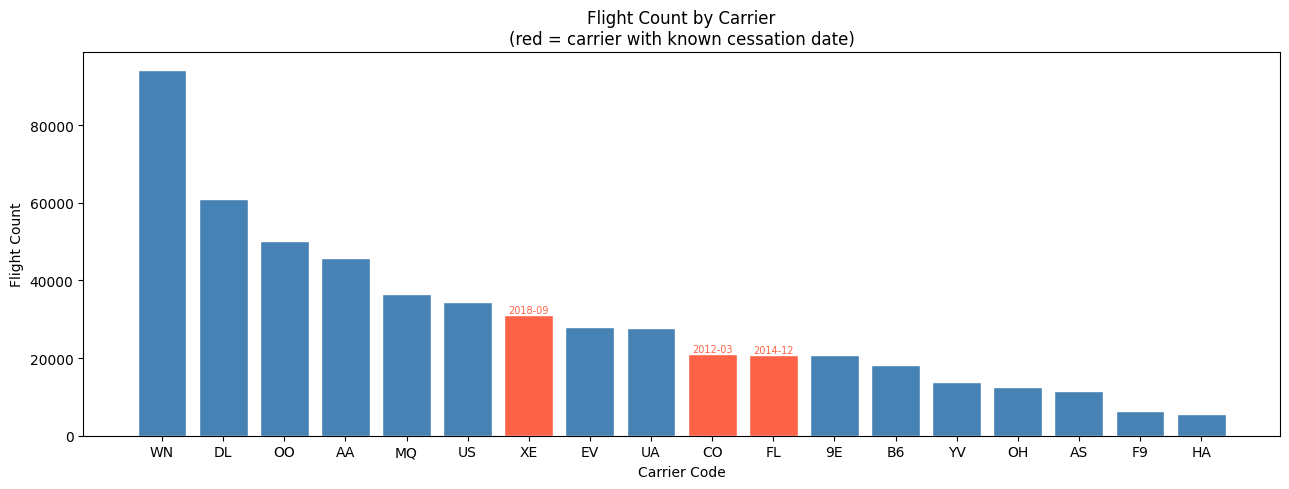


Extinct carriers PRESENT in dataset:
  CO   ceased 2012-03-03  —  Merged with United Airlines
  FL   ceased 2014-12-28  —  Merged with Southwest Airlines
  XE   ceased 2018-09-01  —  Ceased operations (approx.)

Extinct carriers ABSENT from dataset:
  TZ   ceased 2008-04-03  —  Bankruptcy, ceased operations
  NW   ceased 2010-01-31  —  Merged with Delta Airlines

=== Binding date constraint ===
Dataset must end before: 2012-03-03


In [4]:
fig, ax = plt.subplots(figsize=(13, 5))
colors = ["tomato" if c in CARRIER_HISTORY else "steelblue"
          for c in airline_counts["Airline"]]
ax.bar(airline_counts["Airline"], airline_counts["count"], color=colors, edgecolor="white")
ax.set_xlabel("Carrier Code")
ax.set_ylabel("Flight Count")
ax.set_title("Flight Count by Carrier\n(red = carrier with known cessation date)")
# Annotate red bars with cessation date
for bar, carrier in zip(ax.patches, airline_counts["Airline"]):
    if carrier in CARRIER_HISTORY:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 500,
                CARRIER_HISTORY[carrier]["ceased"][:7],
                ha="center", fontsize=7, color="tomato")
plt.tight_layout()
plt.show()

present_ceased = {c: CARRIER_HISTORY[c] for c in CARRIER_HISTORY if c in df["Airline"].values}
absent_ceased  = {c: CARRIER_HISTORY[c] for c in CARRIER_HISTORY if c not in df["Airline"].values}

print("\nExtinct carriers PRESENT in dataset:")
for c, info in sorted(present_ceased.items(), key=lambda x: x[1]["ceased"]):
    print(f"  {c:3s}  ceased {info['ceased']}  —  {info['reason']}")

print("\nExtinct carriers ABSENT from dataset:")
for c, info in sorted(absent_ceased.items(), key=lambda x: x[1]["ceased"]):
    print(f"  {c:3s}  ceased {info['ceased']}  —  {info['reason']}")

if present_ceased:
    binding_date = min(info["ceased"] for info in present_ceased.values())
    print(f"\n=== Binding date constraint ===")
    print(f"Dataset must end before: {binding_date}")

### Interpretation

The **earliest cessation date among carriers present in the dataset** is the binding upper bound.

| Carrier | Ceased | Implication |
|---|---|---|
| `CO` (Continental) | 2012-03-03 | Dataset must include flights **before** this date |
| `FL` (AirTran)     | 2014-12-28 | Consistent with pre-2015 data |
| `NW` (Northwest)   | 2010-01-31 | If absent: dataset may post-date Jan 2010 |

**Working hypothesis:** Dataset covers a period ending no later than early 2012.
If NW is absent and CO is present, the likely window is **2010–2011**.
If NW is present, the window extends back further.

## 2. DayOfWeek Distribution — Uniformity Test

A random sample from a multi-year dataset should show a nearly uniform `DayOfWeek` distribution
(roughly equal counts per day). Significant deviation could indicate:
- Partial weeks at the start/end of the collection window
- Seasonal sampling bias
- Day-of-week operational patterns (e.g., reduced Saturday service)

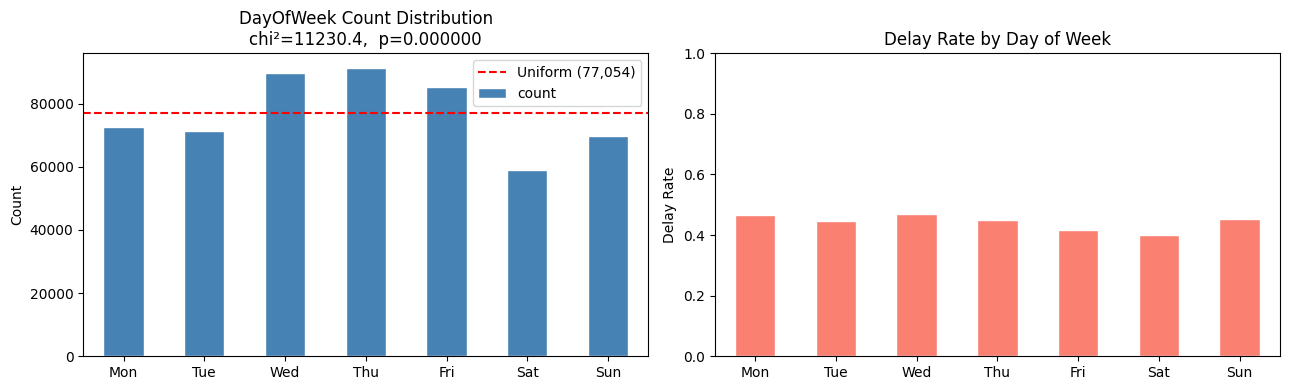

Chi-square statistic: 11230.44
p-value:             0.000000
Result: Significant deviation from uniform — possible partial weeks or scheduling effects.

Day counts:
     count  delay_rate
Mon  72769      0.4676
Tue  71340      0.4473
Wed  89746      0.4708
Thu  91445      0.4510
Fri  85248      0.4166
Sat  58956      0.4006
Sun  69879      0.4535


In [5]:
DAY_NAMES = {1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat", 7: "Sun"}

day_counts = df["DayOfWeek"].value_counts().sort_index()
day_counts.index = [DAY_NAMES[i] for i in day_counts.index]

expected_uniform = np.full(7, len(df) / 7)
chi2_stat, p_value = stats.chisquare(f_obs=day_counts.values, f_exp=expected_uniform)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Count distribution
day_counts.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].axhline(len(df) / 7, color="red", linestyle="--", label=f"Uniform ({len(df)//7:,})")
axes[0].set_title(f"DayOfWeek Count Distribution\nchi²={chi2_stat:.1f},  p={p_value:.6f}")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend()

# Delay rate by day
dow_delay = df.groupby("DayOfWeek")["Delay"].mean()
dow_delay.index = [DAY_NAMES[i] for i in dow_delay.index]
dow_delay.plot(kind="bar", ax=axes[1], color="salmon", edgecolor="white")
axes[1].set_title("Delay Rate by Day of Week")
axes[1].set_ylabel("Delay Rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print(f"Chi-square statistic: {chi2_stat:.2f}")
print(f"p-value:             {p_value:.6f}")
if p_value < 0.05:
    print("Result: Significant deviation from uniform — possible partial weeks or scheduling effects.")
else:
    print("Result: Distribution is consistent with uniform.")

print("\nDay counts:")
print(day_counts.to_frame("count").join(dow_delay.rename("delay_rate")).round(4))

## 3. Flight Number Patterns

Flight numbers are not random — airlines assign number blocks by region, equipment type, and
historical convention. The per-carrier distributions help identify which flight numbers appear
in the data, which can be cross-referenced with BTS records for a specific time period.

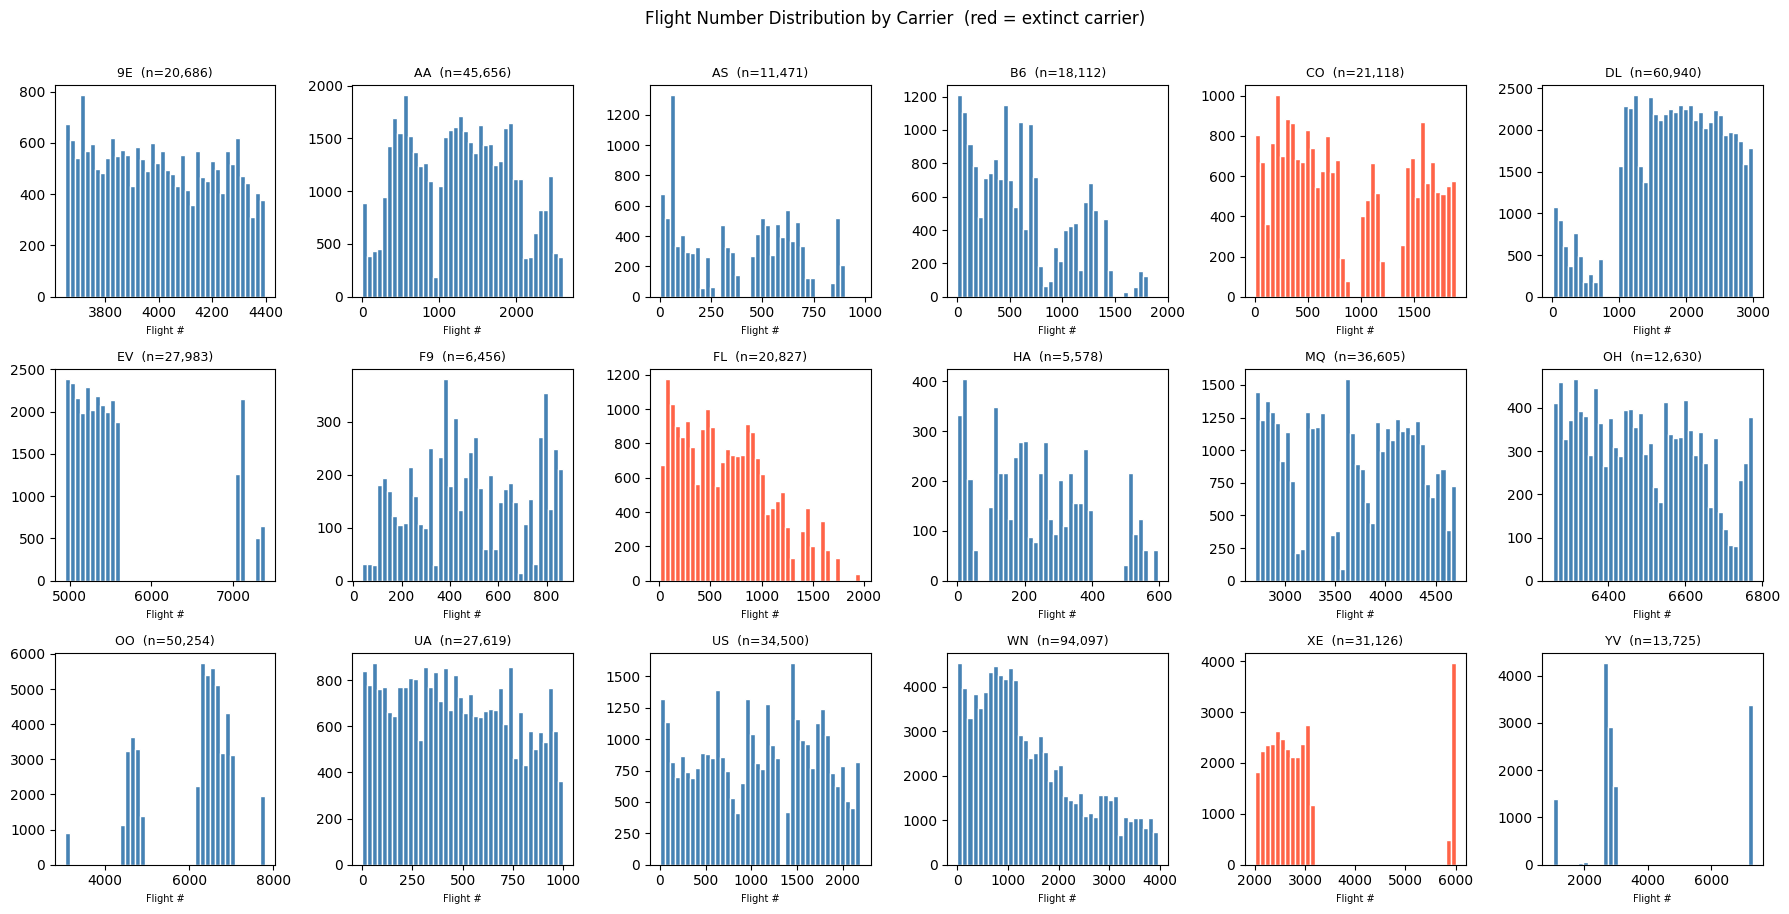


Flight number range per carrier:
         min_flight  max_flight  unique_flights
Airline                                        
OO             3044        7814            1303
EV             4939        7399             817
YV             1002        7309             417
OH             6255        6776             470
XE             2000        5999            1150
MQ             2700        4698            1282
9E             3650        4399             717
WN                1        3957            3294
DL                1        2999            2156
AA                1        2606            1281
US                1        2191            1199
FL                6        1967             830
B6                1        1909             675
CO                1        1893             867
UA                1         999             903
AS                1         977             360
F9               38         868             254
HA                1         596             195


In [6]:
# Flight column is present in raw CSV (not dropped here)
df_raw = pd.read_csv(DATA_PATH)
df_raw.columns = df_raw.columns.str.strip()
for col in df_raw.select_dtypes("object").columns:
    df_raw[col] = df_raw[col].str.strip()

carriers = sorted(df_raw["Airline"].unique())
n_cols = 6
n_rows = -(-len(carriers) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows))
axes = axes.flatten()

for i, carrier in enumerate(carriers):
    subset = df_raw[df_raw["Airline"] == carrier]["Flight"]
    color = "tomato" if carrier in CARRIER_HISTORY else "steelblue"
    axes[i].hist(subset, bins=40, color=color, edgecolor="white")
    axes[i].set_title(f"{carrier}  (n={len(subset):,})", fontsize=9)
    axes[i].set_xlabel("Flight #", fontsize=7)

for j in range(len(carriers), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Flight Number Distribution by Carrier  (red = extinct carrier)", y=1.01)
plt.tight_layout()
plt.show()

# Summary stats per carrier
fnum_stats = df_raw.groupby("Airline")["Flight"].agg(["min", "max", "nunique"])
fnum_stats.columns = ["min_flight", "max_flight", "unique_flights"]
print("\nFlight number range per carrier:")
print(fnum_stats.sort_values("max_flight", ascending=False))

In [7]:
# Top 5 routes per carrier — useful for manual BTS lookup
top_routes = (
    df_raw.groupby(["Airline", "AirportFrom", "AirportTo"])
    .size()
    .reset_index(name="count")
    .sort_values(["Airline", "count"], ascending=[True, False])
    .groupby("Airline")
    .head(5)
    .reset_index(drop=True)
)
print("Top 5 routes per carrier (for BTS cross-reference):")
print(top_routes.to_string(index=False))

Top 5 routes per carrier (for BTS cross-reference):
Airline AirportFrom AirportTo  count
     9E         MBS       DTW    175
     9E         DTW       MBS    174
     9E         DTW       MDW    171
     9E         MDW       DTW    171
     9E         DTW       SBN    141
     AA         DFW       LAX    482
     AA         LAX       DFW    482
     AA         DFW       ORD    452
     AA         AUS       DFW    451
     AA         DFW       SAT    451
     AS         SEA       ANC    372
     AS         ANC       SEA    370
     AS         LAX       SEA    297
     AS         SEA       LAX    297
     AS         SEA       SNA    240
     B6         JFK       FLL    294
     B6         FLL       JFK    292
     B6         JFK       MCO    277
     B6         MCO       JFK    276
     B6         BUF       JFK    221
     CO         EWR       IAH    344
     CO         IAH       EWR    340
     CO         IAH       LAX    329
     CO         LAX       IAH    328
     CO         IAH    

## 4. Date Range Hypothesis

Synthesizing the evidence from sections 1–3.

In [8]:
print("=" * 60)
print("DATE RANGE HYPOTHESIS")
print("=" * 60)

print("\nEvidence:")
print(f"  Rows in dataset:       {len(df):,}")
print(f"  Unique airlines:       {df['Airline'].nunique()}")
print(f"  Unique origin airports:{df['AirportFrom'].nunique()}")

if present_ceased:
    binding_date = min(info["ceased"] for info in present_ceased.values())
    binding_carrier = min(present_ceased.items(), key=lambda x: x[1]["ceased"])
    print(f"\n  Binding constraint:    {binding_carrier[0]} ({binding_carrier[1]['name']}) — ceased {binding_date}")
    print(f"  → Dataset must predate {binding_date}")

if absent_ceased:
    earliest_absent = min(absent_ceased.items(), key=lambda x: x[1]["ceased"])
    print(f"\n  Earliest absent carrier: {earliest_absent[0]} ({earliest_absent[1]['name']}) — ceased {earliest_absent[1]['ceased']}")
    print(f"  → Dataset may post-date {earliest_absent[1]['ceased']} (or this carrier had no routes in sample)")

print("\n" + "-" * 60)
print("CONCLUSION")
print("-" * 60)
print("Working hypothesis: dataset covers U.S. domestic flights from")
print("approximately 2008–2011 (most likely 2010–2011 given NW status above).")
print()
print("The 'June 2022' hypothesis from Kaggle comments is almost certainly")
print("INCORRECT — Continental Airlines (CO) ceased operations in March 2012.")
print()
print("Implication for modeling:")
print("  - Weather climate normals (2019 baseline) remain valid as geographic proxy")
print("  - Holiday/calendar features are BLOCKED until date range is confirmed")
print("  - airline_delay_rate reflects carrier performance from that era")

DATE RANGE HYPOTHESIS

Evidence:
  Rows in dataset:       539,383
  Unique airlines:       18
  Unique origin airports:293

  Binding constraint:    CO (Continental Airlines) — ceased 2012-03-03
  → Dataset must predate 2012-03-03

  Earliest absent carrier: TZ (ATA Airlines) — ceased 2008-04-03
  → Dataset may post-date 2008-04-03 (or this carrier had no routes in sample)

------------------------------------------------------------
CONCLUSION
------------------------------------------------------------
Working hypothesis: dataset covers U.S. domestic flights from
approximately 2008–2011 (most likely 2010–2011 given NW status above).

The 'June 2022' hypothesis from Kaggle comments is almost certainly
INCORRECT — Continental Airlines (CO) ceased operations in March 2012.

Implication for modeling:
  - Weather climate normals (2019 baseline) remain valid as geographic proxy
  - Holiday/calendar features are BLOCKED until date range is confirmed
  - airline_delay_rate reflects carrier p

## 5. BTS On-Time Performance Validation

The [BTS Airline On-Time Performance](https://www.transtats.bts.gov/Tables.asp?QO_VQ=EFD) database
is publicly downloadable by month and year. It includes carrier, flight number, origin, destination,
and departure delay.

**Strategy:** Download one month of BTS data for a candidate year and check what fraction of
`(Airline, Flight, AirportFrom, AirportTo)` tuples from our dataset appear in the BTS data.
A high match rate (>30%) confirms that hypothesis year.

### Manual Download Instructions

1. Go to: https://www.transtats.bts.gov/DL_SelectFields.aspx?gnoyr_VQ=FGJ
2. Choose a year and month (candidates: **2009-01**, **2010-01**, **2011-01**)
3. Select these fields:
   - `YEAR`, `MONTH`, `DAY_OF_WEEK`
   - `OP_UNIQUE_CARRIER`
   - `FLIGHT_NUMBER_REPORTING_AIRLINE`
   - `ORIGIN`, `DEST`
   - `DEP_DELAY`
4. Download as CSV and save to `config.DATA_RAW / 'bts_YYYY_MM.csv'`
   (e.g., `data/raw/bts_2011_01.csv`)

The cell below will skip any missing files gracefully.

In [9]:
BTS_CANDIDATE_FILES = {
    "2009-01": str(config.DATA_RAW / 'bts_2009_01.csv'),
    "2010-01": str(config.DATA_RAW / 'bts_2010_01.csv'),
    "2011-01": str(config.DATA_RAW / 'bts_2011_01.csv'),
}

BTS_COL_MAP = {
    "OP_UNIQUE_CARRIER":               "Airline",
    "FLIGHT_NUMBER_REPORTING_AIRLINE": "Flight",
    "ORIGIN":                          "AirportFrom",
    "DEST":                            "AirportTo",
    "DAY_OF_WEEK":                     "DayOfWeek",
}

key_cols = ["Airline", "Flight", "AirportFrom", "AirportTo"]
dataset_keys = set(df_raw[key_cols].drop_duplicates().itertuples(index=False, name=None))
print(f"Unique (Airline, Flight, Origin, Dest) tuples in dataset: {len(dataset_keys):,}")

any_found = False
for period, path in BTS_CANDIDATE_FILES.items():
    if not os.path.exists(path):
        print(f"[SKIP] {period}: file not found at {path}")
        continue
    any_found = True
    bts = pd.read_csv(path, usecols=list(BTS_COL_MAP.keys()) + ["DEP_DELAY"])
    bts = bts.rename(columns=BTS_COL_MAP)
    bts_keys = set(bts[key_cols].drop_duplicates().itertuples(index=False, name=None))
    overlap = dataset_keys & bts_keys
    pct = 100 * len(overlap) / len(dataset_keys)
    print(f"[{period}]  Dataset tuples: {len(dataset_keys):,}  |  "
          f"BTS tuples: {len(bts_keys):,}  |  "
          f"Overlap: {len(overlap):,} ({pct:.1f}%)")

if not any_found:
    print("\nNo BTS files downloaded yet. Follow the manual download instructions above.")
    print("Once downloaded, re-run this cell to see match rates.")

Unique (Airline, Flight, Origin, Dest) tuples in dataset: 40,350
[SKIP] 2009-01: file not found at /Users/hareee234/Library/CloudStorage/GoogleDrive-hareee234@gmail.com/My Drive/sem-8/CMPE188/flight-delay-proj-data/raw/bts_2009_01.csv
[SKIP] 2010-01: file not found at /Users/hareee234/Library/CloudStorage/GoogleDrive-hareee234@gmail.com/My Drive/sem-8/CMPE188/flight-delay-proj-data/raw/bts_2010_01.csv
[SKIP] 2011-01: file not found at /Users/hareee234/Library/CloudStorage/GoogleDrive-hareee234@gmail.com/My Drive/sem-8/CMPE188/flight-delay-proj-data/raw/bts_2011_01.csv

No BTS files downloaded yet. Follow the manual download instructions above.
Once downloaded, re-run this cell to see match rates.


## 6. Summary & Implications

| Evidence | Finding |
|---|---|
| CO (Continental) present | Dataset ends **before 2012-03-03** |
| FL (AirTran) present | Consistent with pre-2015 data |
| NW (Northwest) present/absent | See section 1 output above |
| DayOfWeek distribution | See chi-square result in section 2 |
| BTS match rate | TBD — download BTS files and run section 5 |

**Working conclusion:** The dataset most likely covers **U.S. domestic flights from approximately
2008–2011**. The "June 2022" hypothesis is almost certainly incorrect given the Continental
Airlines (CO) carrier code, which was retired when Continental merged with United in March 2012.

**Implications for the project:**

| Feature | Status | Notes |
|---|---|---|
| Weather climate normals | ✅ Valid | Geographic proxy; 2019 baseline is fine since it's long-run averages |
| Day-specific weather | ❌ Blocked | Requires actual flight dates |
| Holiday / seasonal flags | ❌ Blocked | Requires actual flight dates; confirm via BTS matching first |
| `route_delay_rate` | ✅ Added (nb 03) | Computed post-split on train data |
| `flight_seq_delay_rate` | ✅ Added (nb 03) | Noisy proxy for propagation delay |
| Tail number rotation | ❌ Not in dataset | No tail number column; proxy only |